---
title: "微调CIFAR10"
author: "逃之夭夭"
date: "2026-05-01"
categories: [deep learning, vision]
image: "images/index.jpg"
---

# CIFAR-10

## Fastai

> The famous [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html)

In [2]:
# !pip install timm
# !pip install evaluate

In [1]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

In [2]:
import timm
from fastai.vision.all import *

In [3]:
cifar_path = untar_data(URLs.CIFAR)

In [4]:
cifar_path.ls()

[Path('/home/tzyy/.fastai/data/cifar10/labels.txt'), Path('/home/tzyy/.fastai/data/cifar10/train'), Path('/home/tzyy/.fastai/data/cifar10/models'), Path('/home/tzyy/.fastai/data/cifar10/test')]

In [5]:
train_path = cifar_path/'train'

In [6]:
train_path.ls()

[Path('/home/tzyy/.fastai/data/cifar10/train/deer'), Path('/home/tzyy/.fastai/data/cifar10/train/airplane'), Path('/home/tzyy/.fastai/data/cifar10/train/bird'), Path('/home/tzyy/.fastai/data/cifar10/train/cat'), Path('/home/tzyy/.fastai/data/cifar10/train/truck'), Path('/home/tzyy/.fastai/data/cifar10/train/ship'), Path('/home/tzyy/.fastai/data/cifar10/train/horse'), Path('/home/tzyy/.fastai/data/cifar10/train/frog'), Path('/home/tzyy/.fastai/data/cifar10/train/automobile'), Path('/home/tzyy/.fastai/data/cifar10/train/dog')]

In [7]:
frog_path = train_path/'frog'

In [8]:
frog = frog_path.ls()[0]
frog

Path('/home/tzyy/.fastai/data/cifar10/train/frog/35672_frog.png')

In [9]:
frog_img = PILImage.create(frog)

In [10]:
tensor(frog_img).shape

torch.Size([32, 32, 3])

<Axes: title={'center': 'FROG'}>

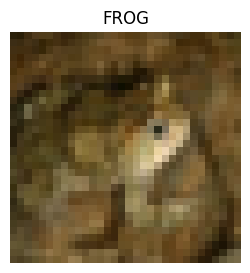

In [11]:
show_image(PILImage.create(frog), figsize=(3, 3), title='FROG')

In [12]:
dls = ImageDataLoaders.from_folder(cifar_path, valid='test')

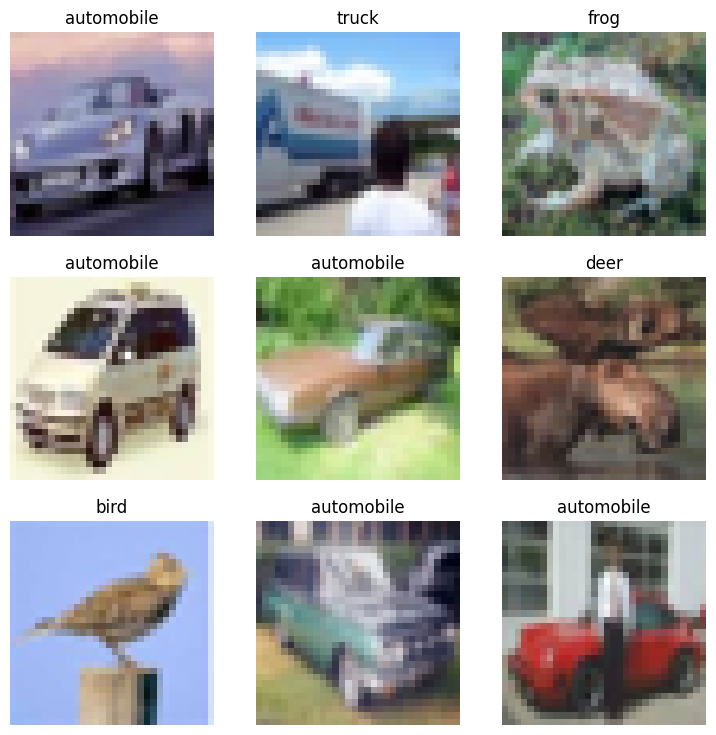

In [13]:
dls.show_batch()

### Resnet18

In [13]:
learner = vision_learner(dls, resnet18, metrics=accuracy, cbs=ActivationStats(with_hist=True))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\ChenBo/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [01:32<00:00, 505kB/s]


SuggestedLRs(valley=0.002511886414140463)

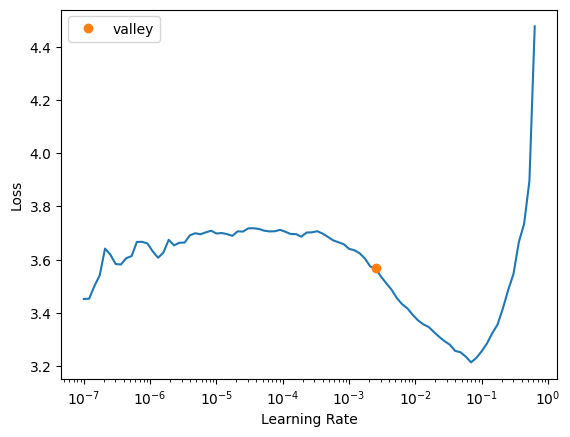

In [15]:
learner.lr_find()

In [16]:
learner.fine_tune(5, 3e-3)

epoch,train_loss,valid_loss,accuracy,time
0,1.624713,1.450234,0.485600,05:30


epoch,train_loss,valid_loss,accuracy,time
0,0.969554,0.845865,0.706800,01:14
1,0.709484,0.675392,0.771300,01:14
2,0.563003,0.614332,0.793900,01:40
3,0.339636,0.613745,0.805200,01:53
4,0.211764,0.657565,0.804300,01:54


<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

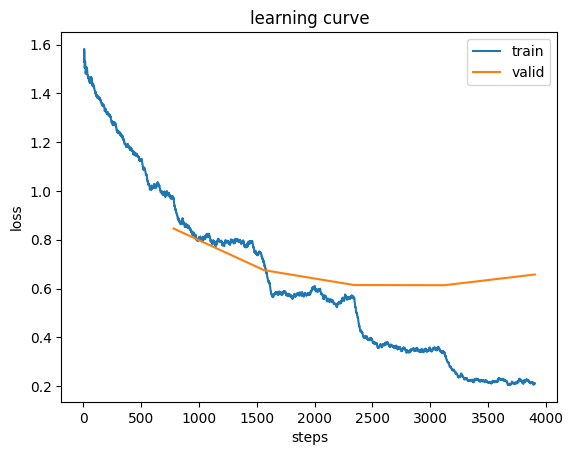

In [17]:
learner.recorder.plot_loss()

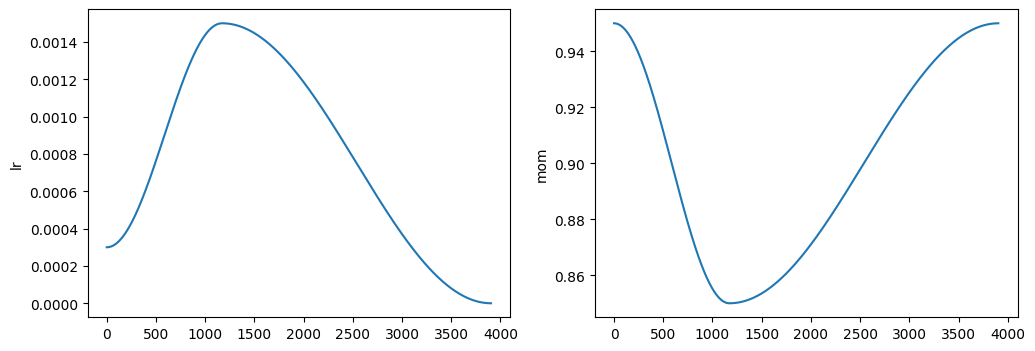

In [18]:
learner.recorder.plot_sched()

In [19]:
learner.recorder.values

[[0.9695535898208618, 0.84586501121521, 0.7067999839782715],
 [0.7094835638999939, 0.675391674041748, 0.7713000178337097],
 [0.5630033016204834, 0.6143324375152588, 0.7939000129699707],
 [0.3396357297897339, 0.6137450933456421, 0.8051999807357788],
 [0.21176433563232422, 0.6575654149055481, 0.8043000102043152]]

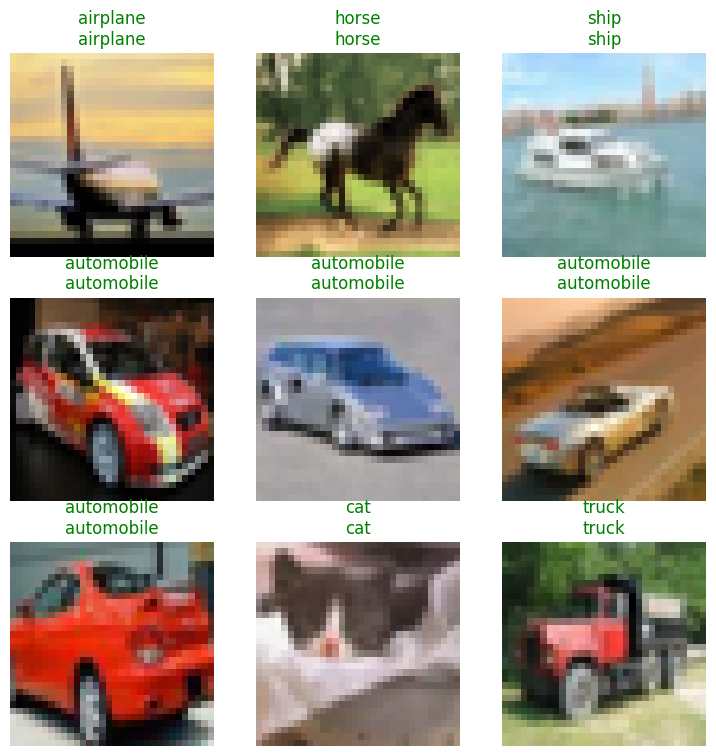

In [20]:
learner.show_results()

In [21]:
learner.summary()

Sequential (Input shape: 64 x 3 x 32 x 32)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 16 x 16   
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 8 x 8     
MaxPool2d                                                      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                        

None


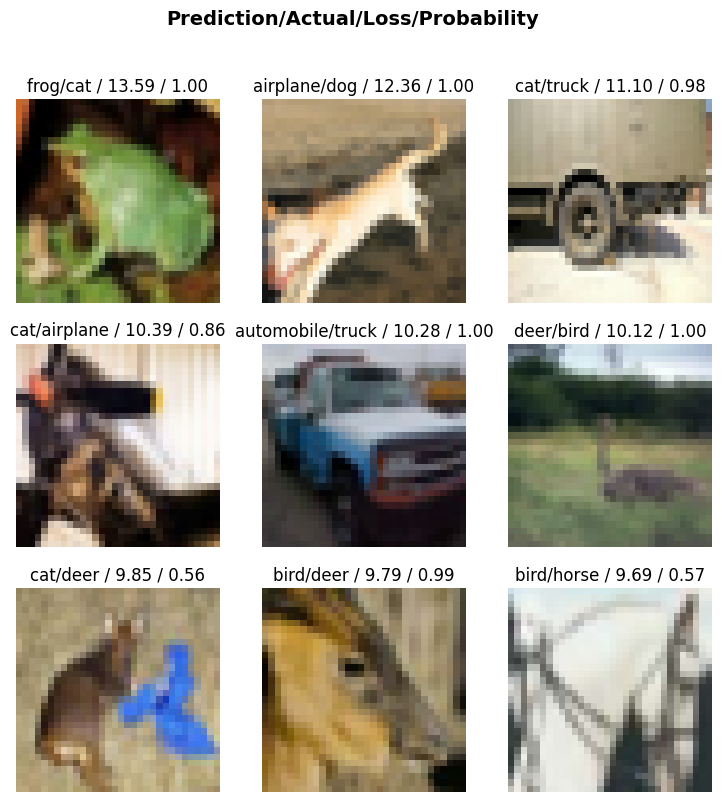

In [22]:
interp = ClassificationInterpretation.from_learner(learner)
print(interp.plot_top_losses(9))

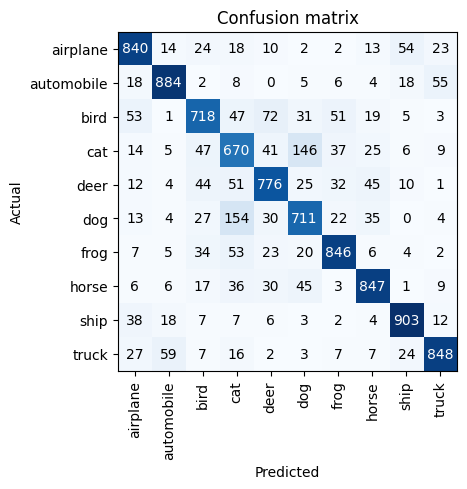

In [23]:
interp.plot_confusion_matrix()

### Retnet18 add Augmentation

In [16]:
dls = ImageDataLoaders.from_folder(cifar_path, valid='test', item_tfms=Resize(236), batch_tfms=aug_transforms(size=224), bs=16)

In [17]:
learner = vision_learner(dls, resnet18, metrics=accuracy, cbs=[ActivationStats(with_hist=True), GradientAccumulation(n_acc=4)])

In [18]:
learner.lr_find()

/home/tzyy/miniconda3/envs/fastai/lib/python3.12/site-packages/fastai/callback/core.py:71: UserWarning: You are shadowing an attribute (modules) that exists in the learner. Use `self.learn.modules` to avoid this
  warn(f"You are shadowing an attribute ({name}) that exists in the learner. Use `self.learn.{name}` to avoid this")


<div><div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div><div></div><div><progress max="3125" value="13"></progress> 0.42% [13/3125 00:05&lt;20:36... 3.7900]</div></div>

KeyboardInterrupt: 

In [19]:
learner.fine_tune(5, 1e-3)

epoch,train_loss,valid_loss,accuracy,time
0,0.752246,0.477425,0.834700,33:42


epoch,train_loss,valid_loss,accuracy,time
0,0.414451,0.260418,0.911500,38:52
1,0.330205,0.211401,0.925800,38:11
2,0.237723,0.168380,0.943000,38:02
3,0.146230,0.141586,0.951300,37:57
4,0.147777,0.135820,0.952600,38:02


### timm/convnext_tiny.in12k_ft_in1k

In [24]:
learner = vision_learner(dls, 'convnext_tiny.in12k_ft_in1k', metrics=accuracy, cbs=ActivationStats(with_hist=True))

d:\program\quarto\blog\.venv\Lib\site-packages\fastai\callback\core.py:71: UserWarning: You are shadowing an attribute (modules) that exists in the learner. Use `self.learn.modules` to avoid this
  warn(f"You are shadowing an attribute ({name}) that exists in the learner. Use `self.learn.{name}` to avoid this")


SuggestedLRs(valley=0.0012022644514217973)

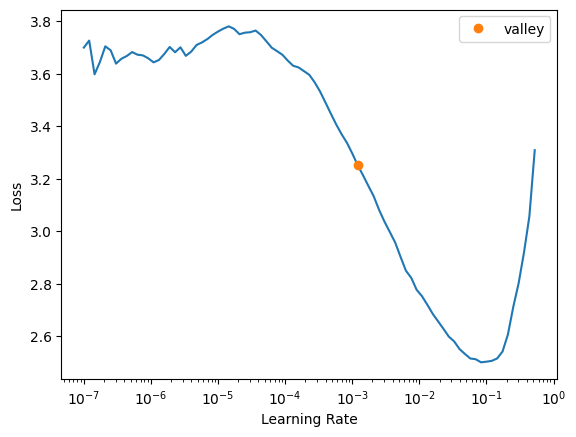

In [25]:
learner.lr_find()

In [26]:
learner.fine_tune(5, 1e-3)

epoch,train_loss,valid_loss,accuracy,time
0,0.807566,0.678986,0.772700,03:58


epoch,train_loss,valid_loss,accuracy,time
0,0.485664,0.416037,0.857700,03:59
1,0.355099,0.330098,0.890000,04:02
2,0.250564,0.305851,0.897600,04:06
3,0.159536,0.306448,0.901600,04:04
4,0.121840,0.309834,0.901700,04:07


<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

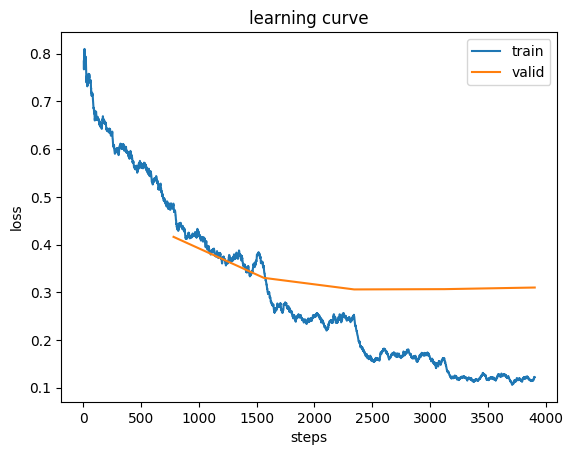

In [27]:
learner.recorder.plot_loss()

None


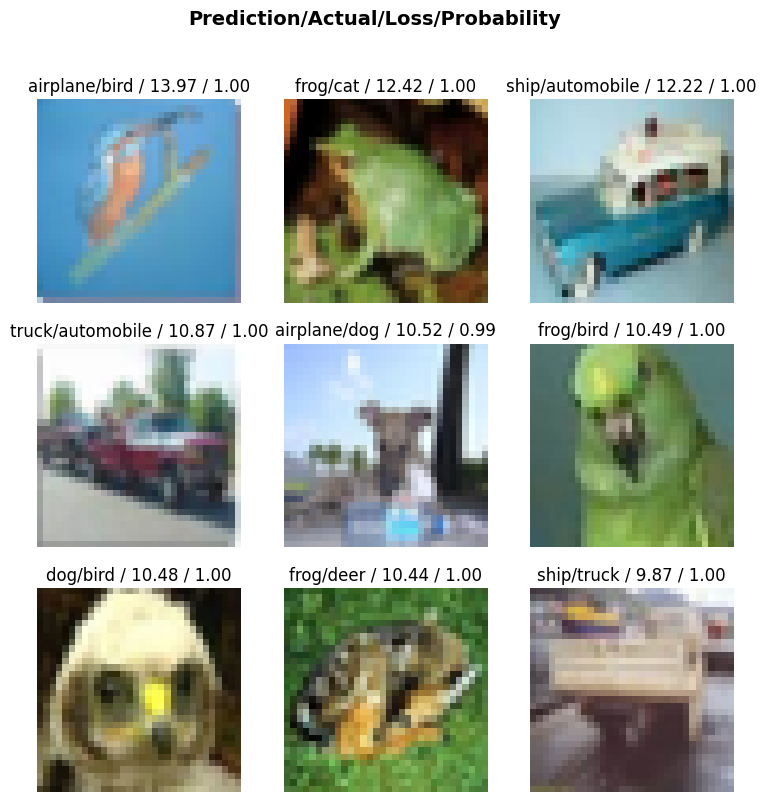

In [28]:
interp = ClassificationInterpretation.from_learner(learner)
print(interp.plot_top_losses(9))

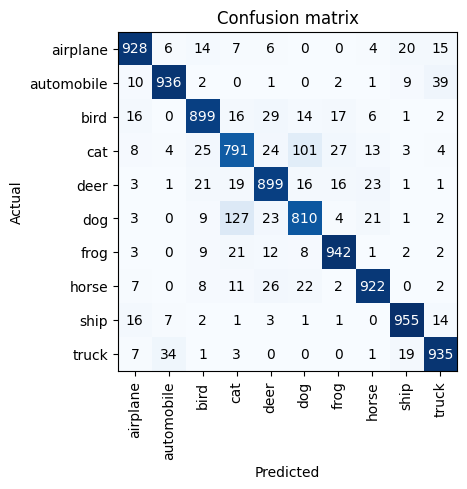

In [29]:
interp.plot_confusion_matrix()

### timm/convnext_tiny.in12k_ft_in1k Add Augmentation

In [14]:
dls = ImageDataLoaders.from_folder(cifar_path, valid='test', item_tfms=Resize(236), batch_tfms=aug_transforms(size=224), bs=16)
learner = vision_learner(dls, 'convnext_tiny.in12k_ft_in1k', metrics=accuracy, cbs=ActivationStats(with_hist=True))
learner.fine_tune(3, 1e-3)

/home/tzyy/miniconda3/envs/fastai/lib/python3.12/site-packages/fastai/callback/core.py:71: UserWarning: You are shadowing an attribute (modules) that exists in the learner. Use `self.learn.modules` to avoid this
  warn(f"You are shadowing an attribute ({name}) that exists in the learner. Use `self.learn.{name}` to avoid this")


epoch,train_loss,valid_loss,accuracy,time
0,0.158725,0.112125,0.966600,1:23:54


epoch,train_loss,valid_loss,accuracy,time
0,0.111598,0.072410,0.977300,1:20:17
1,0.077522,0.063243,0.979900,1:20:14
2,0.021888,0.051781,0.984800,1:20:43


## Use Huuggingface API

### 加载本地数据

In [15]:
from huggingface_hub import notebook_login

notebook_login()

In [16]:
from datasets import load_dataset

In [17]:
dataset = load_dataset(str(cifar_path))

Resolving data files:   0%|          | 0/50000 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/10000 [00:00<?, ?it/s]

In [18]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [19]:
dataset['train'].features['label']

ClassLabel(names=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])

In [20]:
dataset['train'][0]['label']

0

In [21]:
id2label = {}
label2id = {}

for idx, label in enumerate(dataset['train'].features['label'].names):
    id2label[idx] = label
    label2id[label] = idx
    
id2label, label2id

({0: 'airplane',
  1: 'automobile',
  2: 'bird',
  3: 'cat',
  4: 'deer',
  5: 'dog',
  6: 'frog',
  7: 'horse',
  8: 'ship',
  9: 'truck'},
 {'airplane': 0,
  'automobile': 1,
  'bird': 2,
  'cat': 3,
  'deer': 4,
  'dog': 5,
  'frog': 6,
  'horse': 7,
  'ship': 8,
  'truck': 9})

In [22]:
model_name = 'timm/convnext_tiny.in12k_ft_in1k'

### 数据预处理

In [23]:
from transformers import AutoImageProcessor

In [24]:
processor = AutoImageProcessor.from_pretrained(model_name)

Requested torchvision backend is not available. Falling back to pil backend.


In [25]:
processor

TimmWrapperImageProcessor {
  "architecture": "convnext_tiny",
  "data_config": {
    "crop_mode": "center",
    "crop_pct": 0.95,
    "input_size": [
      3,
      224,
      224
    ],
    "interpolation": "bicubic",
    "mean": [
      0.485,
      0.456,
      0.406
    ],
    "std": [
      0.229,
      0.224,
      0.225
    ]
  },
  "image_processor_type": "TimmWrapperImageProcessor"
}

In [26]:
from torchvision.transforms import v2

In [27]:
crop_size = 224
size = math.ceil(crop_size / 0.95)

In [28]:
train_tfms = v2.Compose(
    [v2.RandomResizedCrop(crop_size),
     v2.RandAugment(),
     v2.ToImage(),
     v2.ToDtype(torch.float32, scale=True),
     v2.Normalize(processor.data_config['mean'], processor.data_config['std'])]
)

In [29]:
test_tfms = v2.Compose(
    [v2.Resize(size),
     v2.CenterCrop(crop_size),
     v2.ToImage(),
     v2.ToDtype(torch.float32, scale=True),
     v2.Normalize(processor.data_config['mean'], processor.data_config['std'])]
)

In [30]:
def train_transforms(examples):
    examples["pixel_values"] = [train_tfms(img.convert("RGB")) for img in examples["image"]]
    del examples["image"]
    return examples

In [31]:
def eval_transforms(examples):
    examples["pixel_values"] = [test_tfms(img.convert("RGB")) for img in examples["image"]]
    del examples["image"]
    return examples

In [32]:
train_ds = dataset['train'].with_transform(train_transforms)
eval_ds = dataset['test'].with_transform(eval_transforms)

0


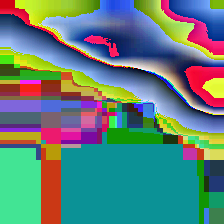

In [33]:
from torchvision.transforms.functional import to_pil_image
print(train_ds[0]['label'])
to_pil_image(train_ds[0]['pixel_values'])

### 准备训练参数

In [34]:
from transformers import TrainingArguments

In [35]:
mn = model_name.split("/")[-1]

In [36]:
batch_size=64

In [37]:
args = TrainingArguments(
    f"{mn}-finetuned-cifar10",
    remove_unused_columns=False,
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=batch_size,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=3,
    warmup_steps=235,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=True,
)

In [38]:
from transformers import AutoModelForImageClassification

In [39]:
model = AutoModelForImageClassification.from_pretrained(model_name, id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True, num_labels=10)

Loading weights:   0%|          | 0/182 [00:00<?, ?it/s]

TimmWrapperForImageClassification LOAD REPORT from: timm/convnext_tiny.in12k_ft_in1k
Key                       | Status   |                                                                                           
--------------------------+----------+-------------------------------------------------------------------------------------------
timm_model.head.fc.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([10])          
timm_model.head.fc.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [40]:
from transformers import Trainer

In [41]:
from transformers import DefaultDataCollator
collator_fn = DefaultDataCollator()

In [42]:
import evaluate

In [43]:
metric = evaluate.load('accuracy')

In [44]:
import numpy as np

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

In [45]:
trainer = Trainer(
    model,
    args,
    data_collator=collator_fn,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    processing_class=processor,
    compute_metrics=compute_metrics
)

In [46]:
train_results = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.473368,0.114332,0.965100
2,0.352160,0.079307,0.973200
3,0.265493,0.056940,0.982600


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

The `save_pretrained` method is disabled for TimmWrapperImageProcessor. The image processor configuration is saved directly in `config.json` when `save_pretrained` is called for saving the model.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [47]:
trainer.save_model()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

In [48]:
trainer.log_metrics("train", train_results.metrics)

***** train metrics *****
  epoch                    =          3.0
  total_flos               = 3511066743GF
  train_loss               =       0.5505
  train_runtime            =   1:03:23.13
  train_samples_per_second =       39.441
  train_steps_per_second   =        0.155


In [49]:
trainer.save_metrics("train", train_results.metrics)

In [50]:
trainer.save_state()

In [52]:
trainer.state.log_history

[{'loss': 2.5530990600585937,
  'grad_norm': 11.174111366271973,
  'learning_rate': 1.9148936170212767e-06,
  'epoch': 0.05115089514066496,
  'step': 10},
 {'loss': 2.261178207397461,
  'grad_norm': 12.512361526489258,
  'learning_rate': 4.0425531914893625e-06,
  'epoch': 0.10230179028132992,
  'step': 20},
 {'loss': 1.9995292663574218,
  'grad_norm': 11.970958709716797,
  'learning_rate': 6.170212765957447e-06,
  'epoch': 0.1534526854219949,
  'step': 30},
 {'loss': 1.6379156112670898,
  'grad_norm': 9.802407264709473,
  'learning_rate': 8.297872340425532e-06,
  'epoch': 0.20460358056265984,
  'step': 40},
 {'loss': 1.3058168411254882,
  'grad_norm': 18.1107120513916,
  'learning_rate': 1.0425531914893617e-05,
  'epoch': 0.2557544757033248,
  'step': 50},
 {'loss': 0.9497040748596192,
  'grad_norm': 30.938528060913086,
  'learning_rate': 1.2553191489361702e-05,
  'epoch': 0.3069053708439898,
  'step': 60},
 {'loss': 0.7797219753265381,
  'grad_norm': 11.254836082458496,
  'learning_ra